# Introduction to Machine Learning (SWE4003)
This content is practice material for the Introduction to Machine Learning (SWE4003) course.

## 2-1. Perceptrons

## [1] McCulloch and Pitts's Neuron Model

First, let's make AND, OR, NAND, NOT gate based on the neuron architecture.

You need to use "y = wx + b" equation with the threshold value of "0"

In [1]:
# ############## Your Code Here ##############
# AND Gate
def AND_gate(x1,y1):
  if x1 == 1 and y1 == 1:
    return 1
  else:
    return 0

# OR Gate
def OR_gate(x1,y1):
  if x1 == 1 or y1 == 1:
    return 1
  else:
    return 0

# NAND Gate
def NAND_gate(x1,y1):
  if x1 == 1 and y1 == 1:
    return 0
  else:
    return 1

# NOT Gate
def NOT_gate(x1):
  if x1 == 1:
    return 0
  else:
    return 1

# ############################################

print(AND_gate(0, 0)) # 0
print(AND_gate(0, 1)) # 0
print(AND_gate(1, 0)) # 0
print(AND_gate(1, 1)) # 1

print(OR_gate(0, 0)) # 0
print(OR_gate(0, 1)) # 1
print(OR_gate(1, 0)) # 1
print(OR_gate(1, 1)) # 1

print(NAND_gate(0, 0)) # 1
print(NAND_gate(0, 1)) # 1
print(NAND_gate(1, 0)) # 1
print(NAND_gate(1, 1)) # 0

print(NOT_gate(0)) # 1
print(NOT_gate(1)) # 0

0
0
0
1
0
1
1
1
1
1
1
0
1
0


## [2] Training a Perceptron Model

Now, let's train a perceptron model with a toydataset.

## Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir("/content/drive/MyDrive/기계학습개론/2주차_실습/")

## Preparing a toy dataset

In [7]:
#***************#
#*** DATASET ***#
#***************#

data = np.genfromtxt('data/perceptron_toydata.txt', delimiter='\t') # open toydata
X, y = data[:, :2], data[:, 2]
y = y.astype(np.int32)

print('Class label counts:', np.bincount(y)) # print some information
print('X.shape:', X.shape)
print('y.shape:', y.shape)

# Shuffling & train/test split
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx) # shuffle index (X, y) together => get random order
X, y = X[shuffle_idx], y[shuffle_idx]

# ############## Your Code Here ##############
# Use 70 data point as train set, and use 30 data point as test set
X_train, X_test = X[:70], X[70:]
y_train, y_test = y[:70], y[70:]
# ############################################


# ############## Your Code Here ##############
# Normalize train and test set (mean zero, unit variance) -> so called "standardization" (subtract the mean and divide by the standard deviation)
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0) # get mean, standard deviation
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma
# ############################################

Class label counts: [50 50]
X.shape: (100, 2)
y.shape: (100,)


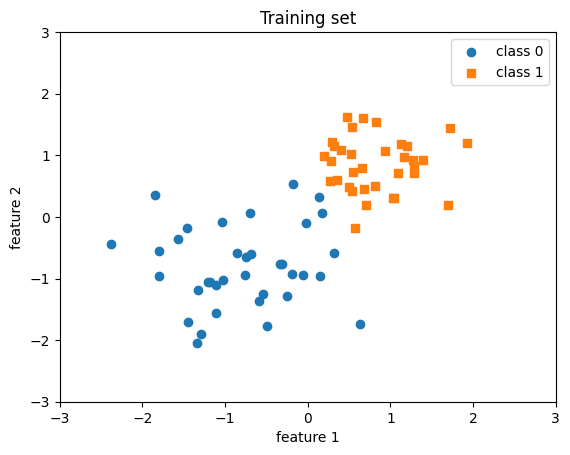

In [8]:
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o') # get data
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

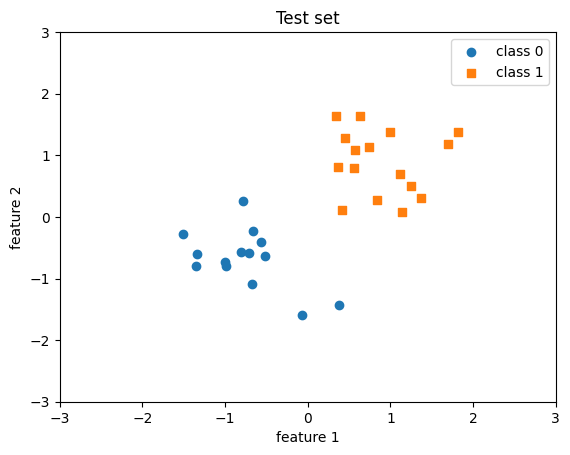

In [9]:
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')
plt.title('Test set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()

## Defining the Perceptron model

In [10]:
class Perceptron(): # implement class
    def __init__(self, num_features):
        self.num_features = num_features
        self.weights = np.zeros((num_features, 1), dtype=np.float64)
        # e.g. the number of feature (x_1, ..., x_m)
        # e.g. iris -> sepal length, sepal width, petal length, petal width (m=4)
        self.bias = np.zeros(1, dtype=np.float64) # single value of 1

    def forward(self, x):
        # ############## Your Code Here ##############
        # Computing net inputs
        net_input = np.dot(x, self.weights) + self.bias
        predictions = np.where(net_input > 0, 1, 0)
        # Apply threshold function to the net input using np.where

        # ############################################
        return predictions

    def backward(self, x, y): # for computing the errors and update
        # ############## Your Code Here ##############
        predictions = self.forward(x)
        errors = y - predictions
        # ############################################
        return errors

    def train(self, x, y, epochs): # train methods
        for e in range(epochs):
            for i in range(y.shape[0]): # every training examples
                errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1) # call backward
                # use .reshape for dimension match
                # x[i]: (num_features, 1) --.reshape--> (1, num_features), weights: (num_features, 1) => so we can dot product two vectors
                # ############## Your Code Here ##############
                # update weights and bias
                self.weights = self.weights + x[i].reshape(self.num_features, 1) * errors
                self.bias = self.bias + errors
                # ############################################

    def evaluate(self, x, y):
        predictions = self.forward(x).reshape(-1)
        # ############## Your Code Here ##############
        # Compute how many predictions were correct ((1) use np.sum, (2) the number of y: y.shape[0])
        accuracy = np.sum(predictions == y) / y.shape[0]
        # ############################################
        return accuracy

## Training the Perceptron

In [11]:
ppn = Perceptron(num_features=2) # initialize

ppn.train(X_train, y_train, epochs=5) # training perceptron

print('Model parameters:\n\n')
print('  Weights: %s\n' % ppn.weights)
print('  Bias: %s\n' % ppn.bias)

Model parameters:


  Weights: [[2.51773646]
 [0.88360504]]

  Bias: [-1.]



## Evaluating the model

In [12]:
test_acc = ppn.evaluate(X_test, y_test)
print('Test set accuracy: %.2f%%' % (test_acc*100)) # may overfit to train dataset

train_acc = ppn.evaluate(X_train, y_train)
print('Train set accuracy: %.2f%%' % (train_acc*100)) # we already trained model

Test set accuracy: 100.00%
Train set accuracy: 100.00%


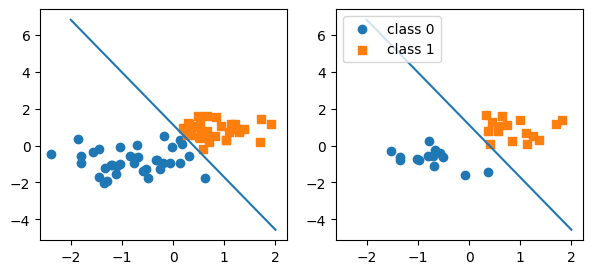

In [13]:
# Let's look at the 2D Decision Boundary

w, b = ppn.weights, ppn.bias

x_min = -2 # rearange the limits of x axis and y axis
y_min = ( (-(w[0] * x_min) - b[0]) # set x_min to 2 and its corresponding y value will be...
          / w[1] )
# x0*w0 + x1*w1 + b = 0 original one
# x1*w1 = -x0*w0 - b
# x1 = (-x0*w0 -b) / w1

x_max = 2
y_max = ( (-(w[0] * x_max) - b[0])
          / w[1] )


fig, ax = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

# training set
ax[0].plot([x_min, x_max], [y_min, y_max])
ax[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
ax[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')

# test set
ax[1].plot([x_min, x_max], [y_min, y_max])
ax[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
ax[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')

ax[1].legend(loc='upper left')
plt.show()